In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)


df = pd.read_csv('machine_temperature_system_failure.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')
df = df.sort_index()

print("Размерность данных:", df.shape)
print("\nПервые 5 строк:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())

Размерность данных: (22695, 1)

Первые 5 строк:
                         value
timestamp                     
2013-12-02 21:15:00  73.967322
2013-12-02 21:20:00  74.935882
2013-12-02 21:25:00  76.124162
2013-12-02 21:30:00  78.140707
2013-12-02 21:35:00  79.329836

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 22695 entries, 2013-12-02 21:15:00 to 2014-02-19 15:25:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   22695 non-null  float64
dtypes: float64(1)
memory usage: 354.6 KB
None


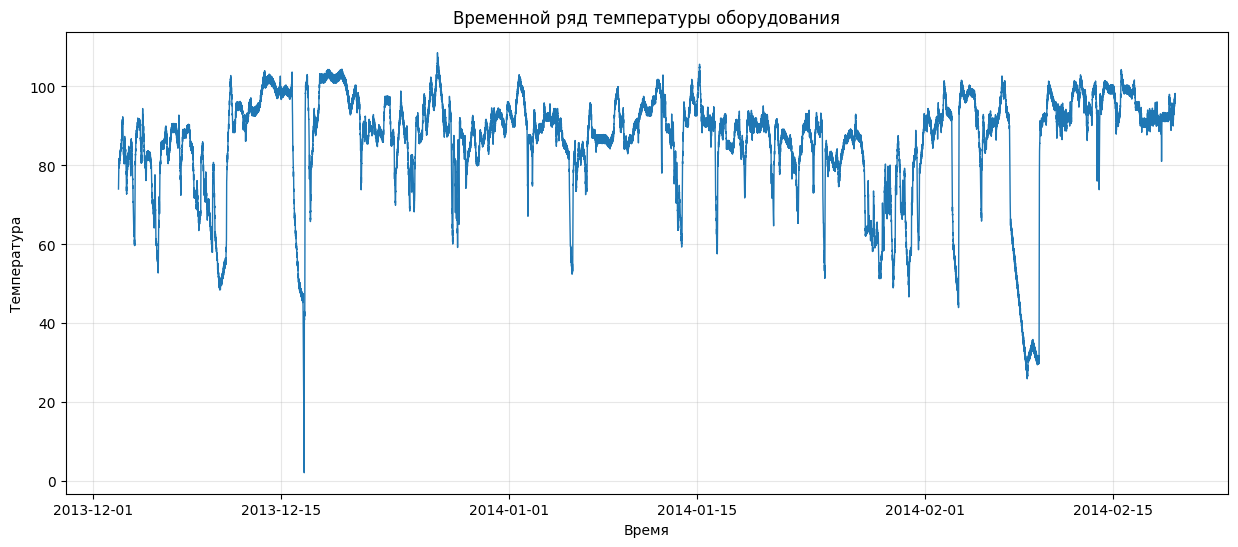

Основные статистики:
              value
count  22695.000000
mean      85.926498
std       13.746912
min        2.084721
25%       83.080078
50%       89.408246
75%       94.016252
max      108.510543

Пропущенные значения: 0


In [2]:
# Визуализация временного ряда
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['value'], linewidth=1)
plt.title('Временной ряд температуры оборудования')
plt.xlabel('Время')
plt.ylabel('Температура')
plt.grid(True, alpha=0.3)
plt.show()

# Анализ основных статистик
print("Основные статистики:")
print(df.describe())

# Проверка на пропущенные значения
print(f"\nПропущенные значения: {df.isnull().sum().sum()}")

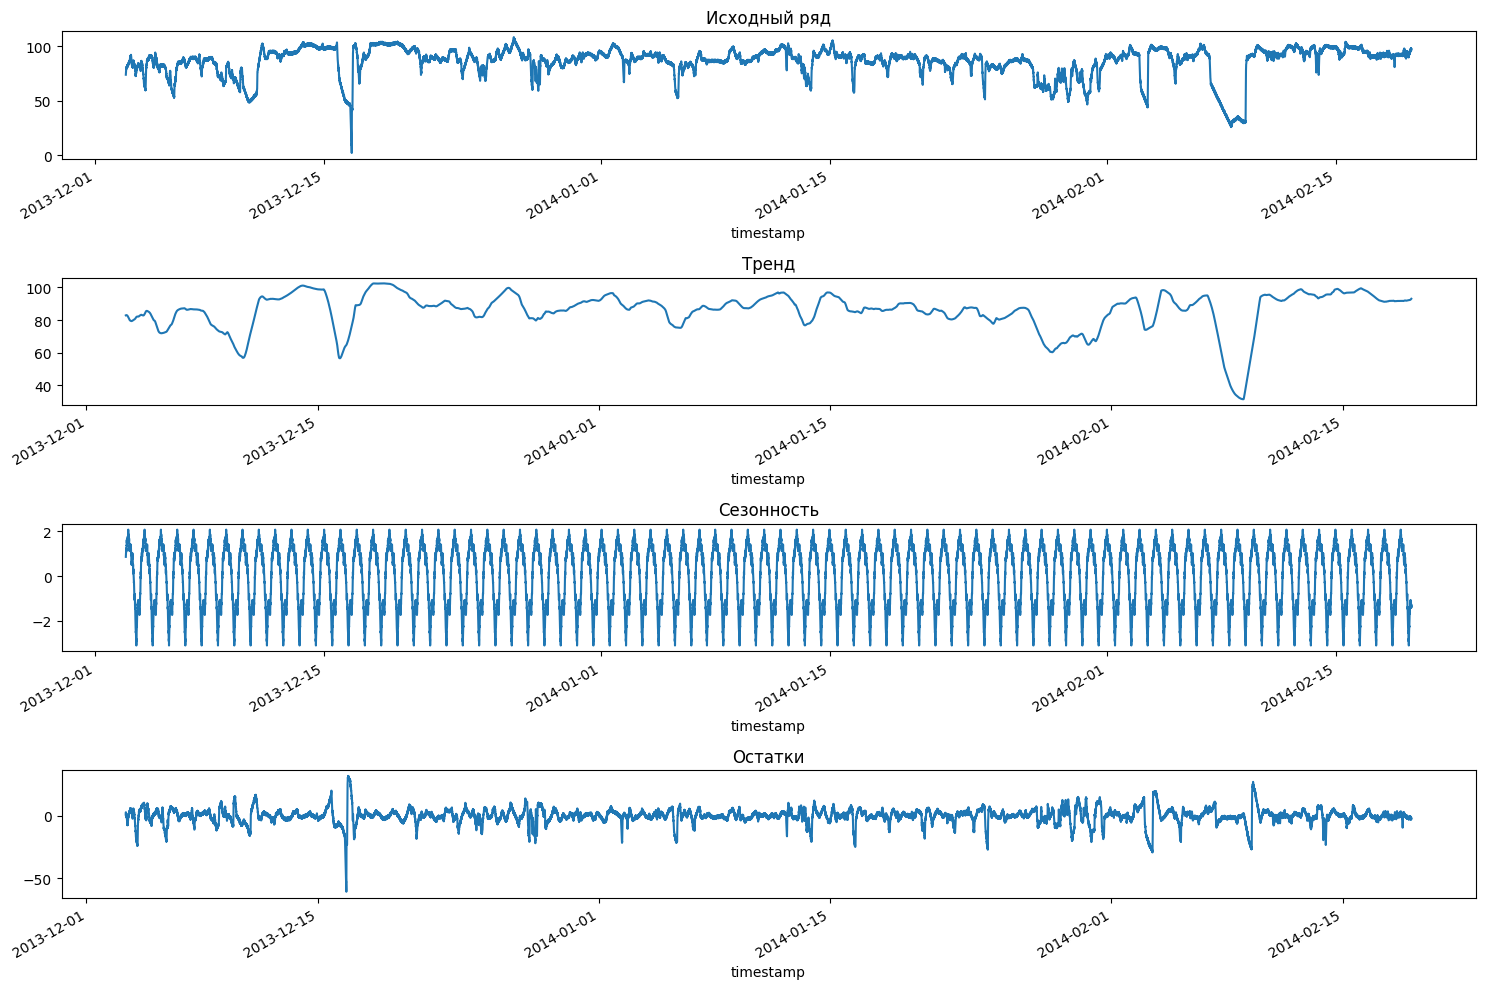

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Декомпозиция ряда
decomposition = seasonal_decompose(df['value'], model='additive', period=288)  # 288 = 24ч * 12 измерений в час

fig, axes = plt.subplots(4, 1, figsize=(15, 10))
decomposition.observed.plot(ax=axes[0], title='Исходный ряд')
decomposition.trend.plot(ax=axes[1], title='Тренд')
decomposition.seasonal.plot(ax=axes[2], title='Сезонность')
decomposition.resid.plot(ax=axes[3], title='Остатки')
plt.tight_layout()
plt.show()

Train size: 18156
Test size: 4539


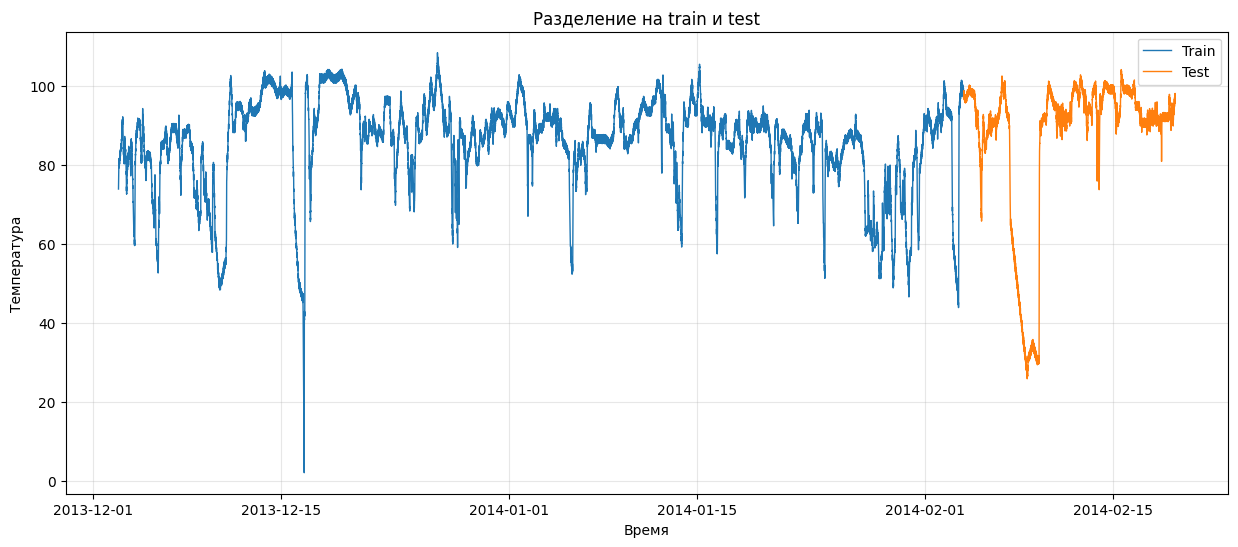

In [4]:
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

print(f"Train size: {len(train)}")
print(f"Test size: {len(test)}")

# Визуализация разделения
plt.figure(figsize=(15, 6))
plt.plot(train.index, train['value'], label='Train', linewidth=1)
plt.plot(test.index, test['value'], label='Test', linewidth=1)
plt.title('Разделение на train и test')
plt.xlabel('Время')
plt.ylabel('Температура')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_metrics(y_true, y_pred):
    #Расчет метрик качества
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape
    }

# Naive прогноз
naive_forecast = np.roll(test['value'].values, 1)
naive_forecast[0] = train['value'].iloc[-1]

# Скользящее среднее
window_size = 12
rolling_mean_forecast = train['value'].rolling(window=window_size).mean().iloc[-1]
rolling_forecast = np.full(len(test), rolling_mean_forecast)

# Расчет метрик для бейзлайнов
naive_metrics = calculate_metrics(test['value'], naive_forecast)
rolling_metrics = calculate_metrics(test['value'], rolling_forecast)

print("Метрики для naive прогноза:")
for metric, value in naive_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nМетрики для скользящего среднего:")
for metric, value in rolling_metrics.items():
    print(f"{metric}: {value:.4f}")

Метрики для naive прогноза:
MAE: 0.8229
MSE: 1.0940
RMSE: 1.0459
MAPE: 1.0639

Метрики для скользящего среднего:
MAE: 12.0680
MSE: 508.1037
RMSE: 22.5412
MAPE: 26.4847


Данные имеют высокую автокорреляцию, naive прогноз дал куда лучший результат в сравнении с скользящим средним

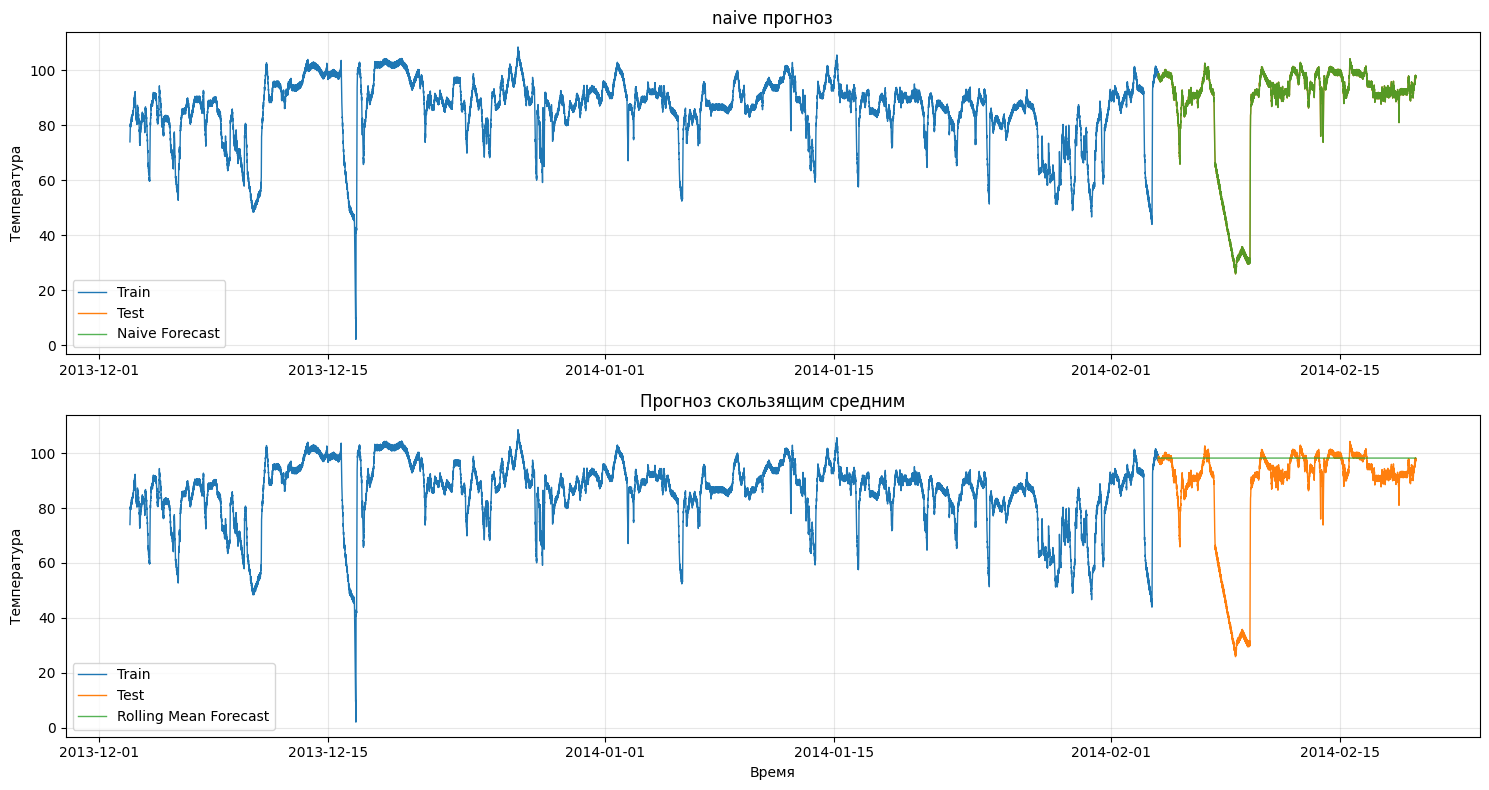

In [6]:
# Визуализация бейзлайнов
plt.figure(figsize=(15, 8))

plt.subplot(2, 1, 1)
plt.plot(train.index, train['value'], label='Train', linewidth=1)
plt.plot(test.index, test['value'], label='Test', linewidth=1)
plt.plot(test.index, naive_forecast, label='Naive Forecast', linewidth=1, alpha=0.8)
plt.title('naive прогноз')
plt.ylabel('Температура')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(train.index, train['value'], label='Train', linewidth=1)
plt.plot(test.index, test['value'], label='Test', linewidth=1)
plt.plot(test.index, rolling_forecast, label='Rolling Mean Forecast', linewidth=1, alpha=0.8)
plt.title('Прогноз скользящим средним')
plt.xlabel('Время')
plt.ylabel('Температура')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Статистический анализ
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Тест Дики-Фуллера на стационарность
def adf_test(timeseries):
    print('Результаты теста Дики-Фуллера:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4],
                        index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

    if dftest[1] <= 0.05:
        print("\nВывод: Ряд стационарен (отвергаем H0)")
    else:
        print("\nВывод: Ряд нестационарен (не отвергаем H0)")

adf_test(train['value'])

Результаты теста Дики-Фуллера:
Test Statistic                -7.837632e+00
p-value                        6.055169e-12
#Lags Used                     2.300000e+01
Number of Observations Used    1.813200e+04
Critical Value (1%)           -3.430711e+00
Critical Value (5%)           -2.861699e+00
Critical Value (10%)          -2.566855e+00
dtype: float64

Вывод: Ряд стационарен (отвергаем H0)


dftest выдал число меньше 0.05 сл-но ряд стационарен

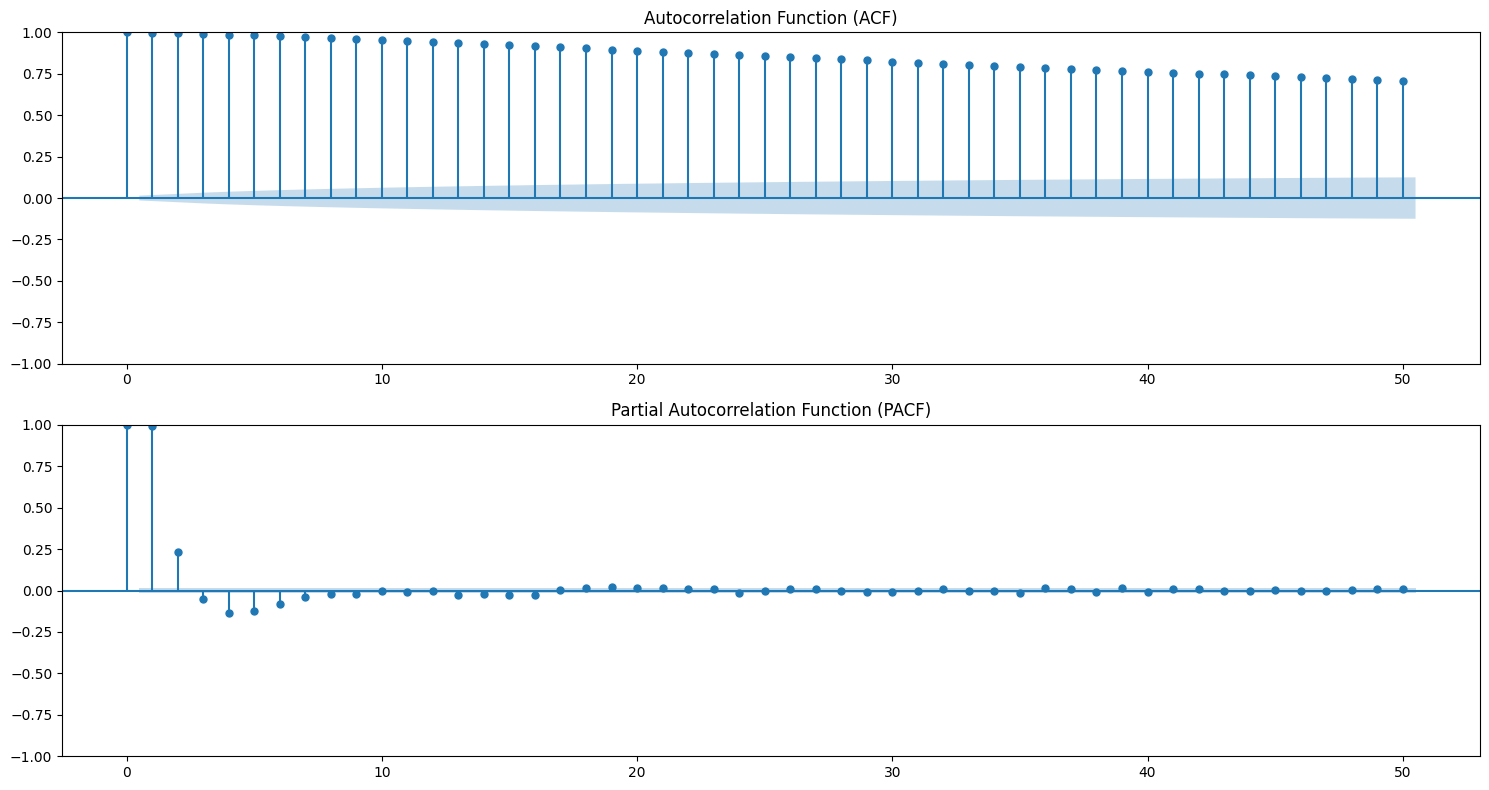

In [8]:
# ACF и PACF графики
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

plot_acf(train['value'], ax=axes[0], lags=50)
axes[0].set_title('Autocorrelation Function (ACF)')

plot_pacf(train['value'], ax=axes[1], lags=50)
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

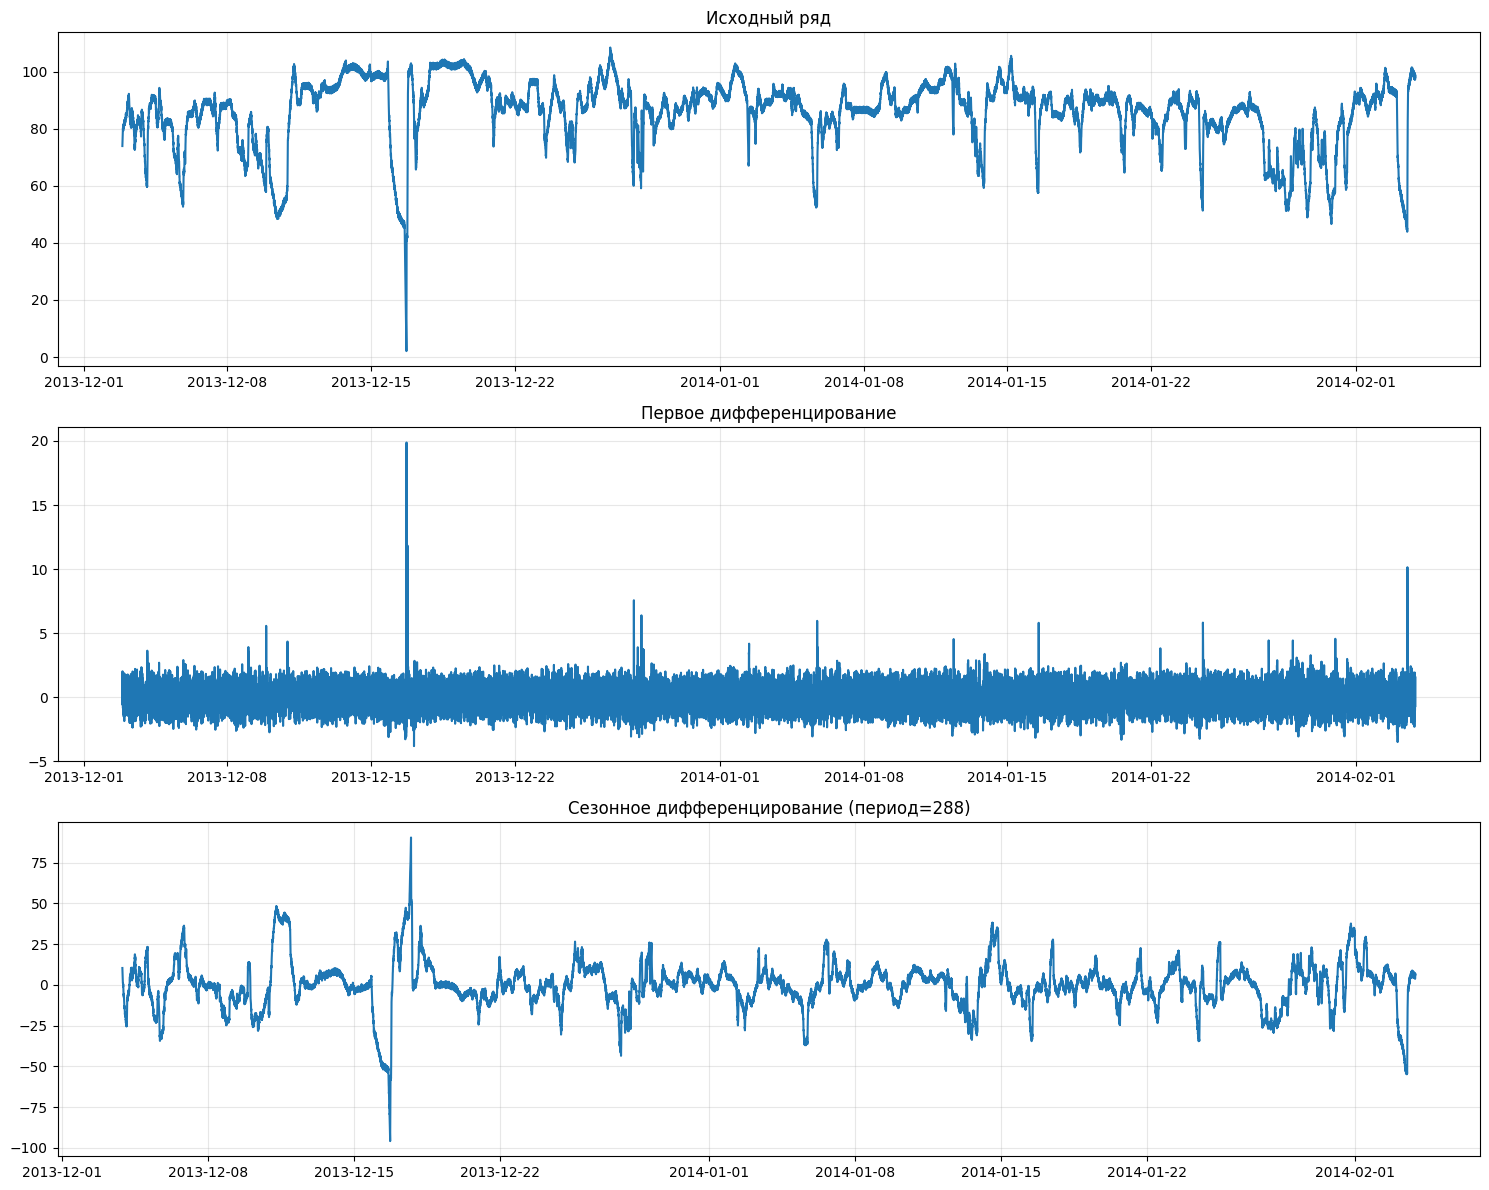

После первого дифференцирования:
Результаты теста Дики-Фуллера:
Test Statistic                   -26.212310
p-value                            0.000000
#Lags Used                        22.000000
Number of Observations Used    18132.000000
Critical Value (1%)               -3.430711
Critical Value (5%)               -2.861699
Critical Value (10%)              -2.566855
dtype: float64

Вывод: Ряд стационарен (отвергаем H0)

После сезонного дифференцирования:
Результаты теста Дики-Фуллера:
Test Statistic                -8.680884e+00
p-value                        4.289367e-14
#Lags Used                     3.800000e+01
Number of Observations Used    1.782900e+04
Critical Value (1%)           -3.430717e+00
Critical Value (5%)           -2.861702e+00
Critical Value (10%)          -2.566856e+00
dtype: float64

Вывод: Ряд стационарен (отвергаем H0)


In [9]:
# Первое дифференцирование
train_diff = train['value'].diff().dropna()

# Сезонное дифференцирование (период 288 - сутки)
train_seasonal_diff = train['value'].diff(288).dropna()

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Исходный ряд
axes[0].plot(train.index, train['value'])
axes[0].set_title('Исходный ряд')
axes[0].grid(True, alpha=0.3)

# Первое дифференцирование
axes[1].plot(train_diff.index, train_diff)
axes[1].set_title('Первое дифференцирование')
axes[1].grid(True, alpha=0.3)

# Сезонное дифференцирование
axes[2].plot(train_seasonal_diff.index, train_seasonal_diff)
axes[2].set_title('Сезонное дифференцирование (период=288)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Проверка стационарности после преобразований
print("После первого дифференцирования:")
adf_test(train_diff)

print("\nПосле сезонного дифференцирования:")
adf_test(train_seasonal_diff)

Анализ теста Дики-Фуллера показал, что исходный ряд температуры оборудования является стационарным (p-value ≈ 0), из чего следует эффективность простейших моделей прогнозирования. Наивный прогноз, использующий только последнее значение, демонстрирует лучшие результаты (MAE = 0.82, RMSE = 1.05)

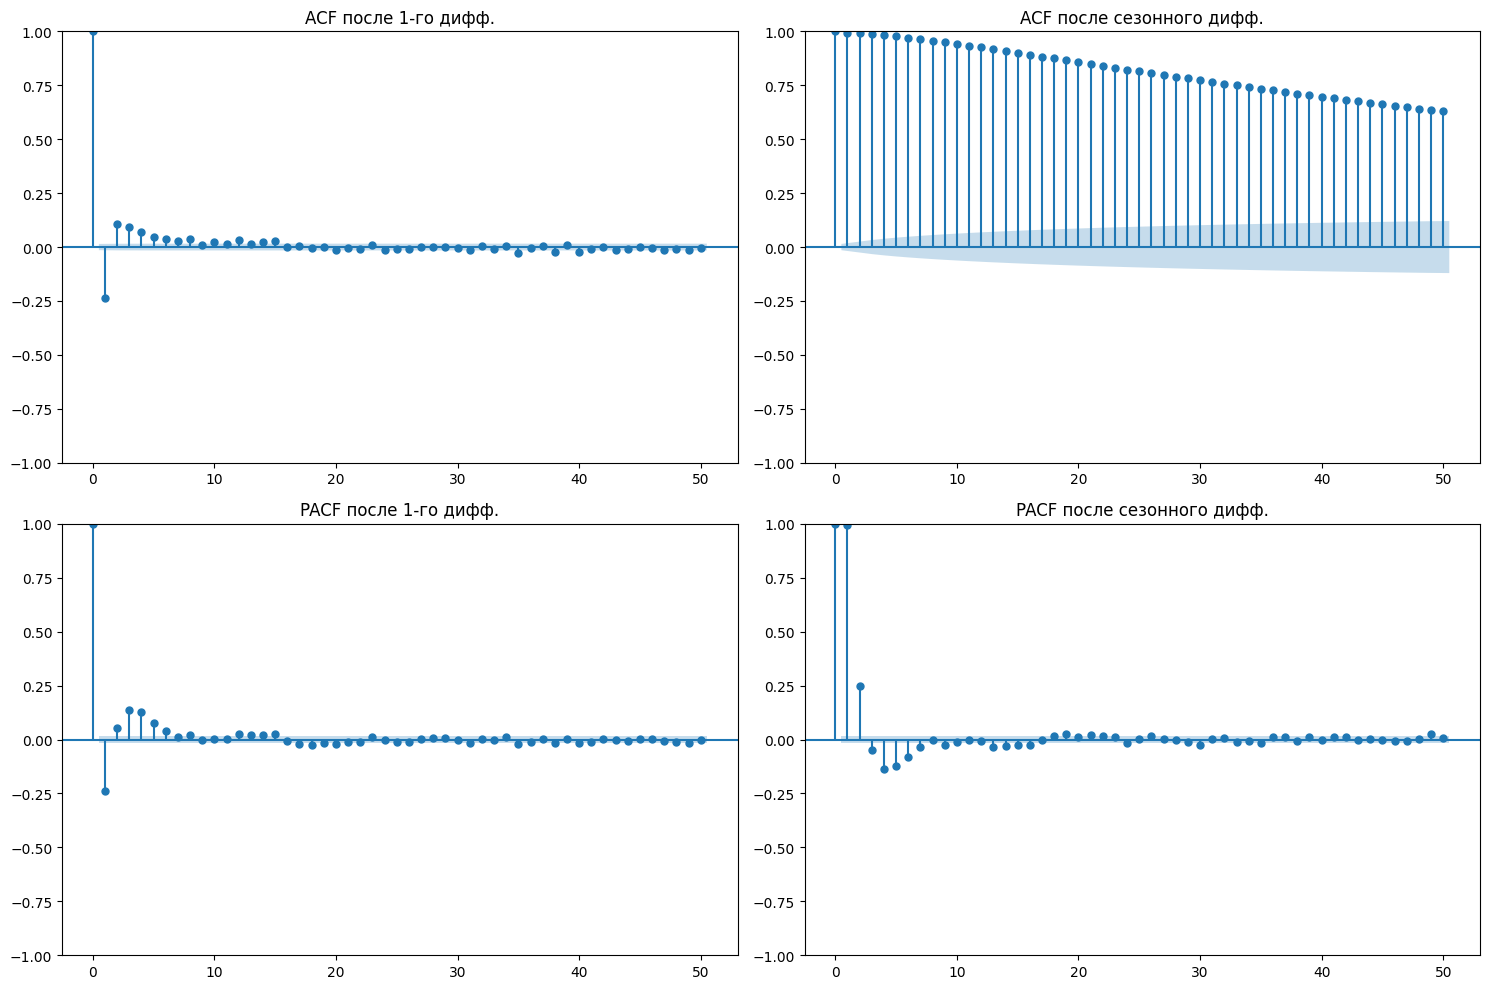

In [10]:
# ACF/PACF после преобразований
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

plot_acf(train_diff, ax=axes[0, 0], lags=50)
axes[0, 0].set_title('ACF после 1-го дифф.')

plot_pacf(train_diff, ax=axes[1, 0], lags=50)
axes[1, 0].set_title('PACF после 1-го дифф.')

plot_acf(train_seasonal_diff, ax=axes[0, 1], lags=50)
axes[0, 1].set_title('ACF после сезонного дифф.')

plot_pacf(train_seasonal_diff, ax=axes[1, 1], lags=50)
axes[1, 1].set_title('PACF после сезонного дифф.')

plt.tight_layout()
plt.show()

In [11]:
from statsmodels.tsa.arima.model import ARIMA
import itertools

# Поиск оптимальных параметров для ARIMA
def find_best_arima(train_data, p_range, d_range, q_range):
    """Поиск лучших параметров ARIMA"""
    best_aic = np.inf
    best_order = None
    best_model = None

    for p, d, q in itertools.product(p_range, d_range, q_range):
        try:
            model = ARIMA(train_data, order=(p, d, q))
            fitted_model = model.fit()
            if fitted_model.aic < best_aic:
                best_aic = fitted_model.aic
                best_order = (p, d, q)
                best_model = fitted_model
        except:
            continue

    return best_order, best_model, best_aic

# Поиск параметров
p_range = range(0, 3)
d_range = range(0, 2)
q_range = range(0, 3)

best_order, best_arima_model, best_aic = find_best_arima(train['value'], p_range, d_range, q_range)
print(f"Лучшие параметры ARIMA: {best_order}, AIC: {best_aic:.2f}")

# Прогноз ARIMA
arima_forecast = best_arima_model.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Лучшие параметры ARIMA: (2, 0, 2), AIC: 52542.64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


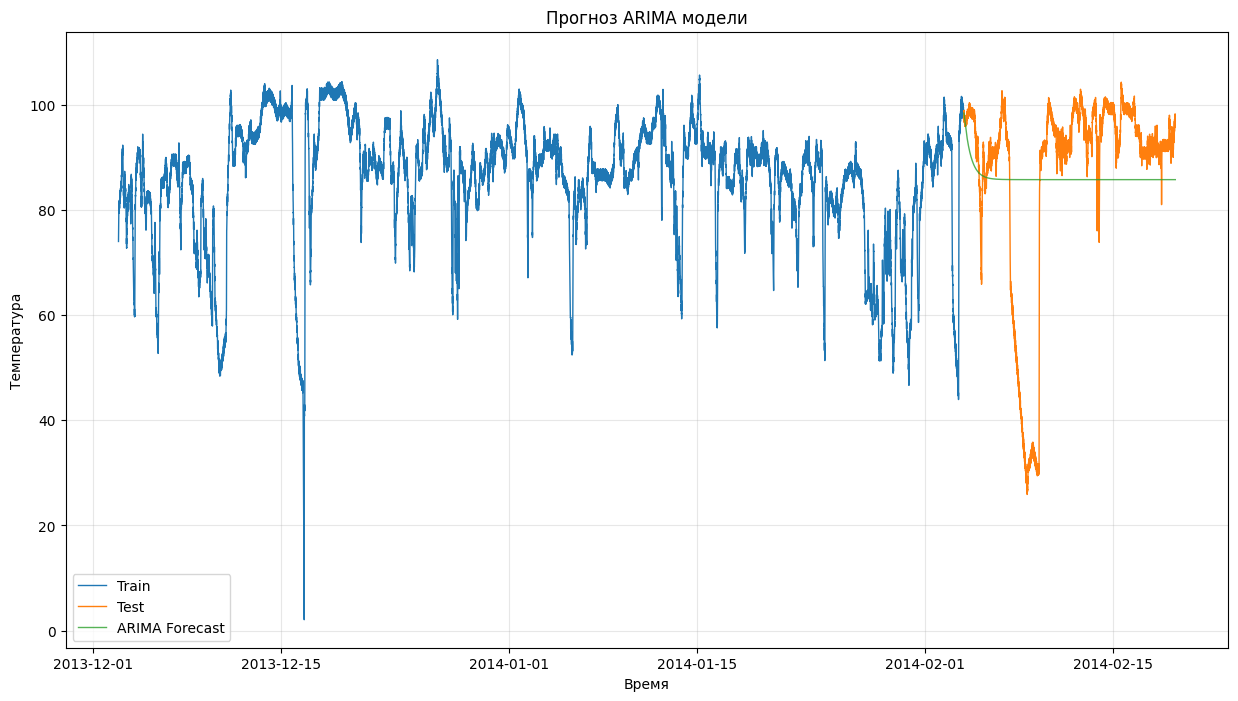

Метрики ARIMA:
MAE: 13.4618
MSE: 372.8873
RMSE: 19.3103
MAPE: nan


In [12]:
# Визуализация и оценка ARIMA
plt.figure(figsize=(15, 8))

plt.plot(train.index, train['value'], label='Train', linewidth=1)
plt.plot(test.index, test['value'], label='Test', linewidth=1)
plt.plot(test.index, arima_forecast, label='ARIMA Forecast', linewidth=1, alpha=0.8)


plt.title('Прогноз ARIMA модели')
plt.xlabel('Время')
plt.ylabel('Температура')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Метрики для ARIMA
arima_metrics = calculate_metrics(test['value'], arima_forecast)
print("Метрики ARIMA:")
for metric, value in arima_metrics.items():
    print(f"{metric}: {value:.4f}")

Результаты ARIMA показывают значительное ухудшение качества по сравнению с наивным прогнозом: MAE 13.46 и RMSE 19.31. Это свидетельствует о том, что ARIMA модель переобучилась или неправильно специфицирована для данного стационарного ряда. Значение MAPE = NaN дополнительно указывает на возможные проблемы с вычислениями

In [13]:
# Классические ML модели
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Feature Engineering
def create_features(df, max_lags=24, window_sizes=[6, 12, 24]):
    """Создание признаков для временного ряда"""
    df_feat = df.copy()

    # Лаги
    for lag in range(1, max_lags + 1):
        df_feat[f'lag_{lag}'] = df_feat['value'].shift(lag)

    # Скользящие статистики
    for window in window_sizes:
        df_feat[f'rolling_mean_{window}'] = df_feat['value'].rolling(window=window).mean()
        df_feat[f'rolling_std_{window}'] = df_feat['value'].rolling(window=window).std()
        df_feat[f'rolling_min_{window}'] = df_feat['value'].rolling(window=window).min()
        df_feat[f'rolling_max_{window}'] = df_feat['value'].rolling(window=window).max()

    # Признаки времени
    df_feat['hour'] = df_feat.index.hour
    df_feat['dayofweek'] = df_feat.index.dayofweek
    df_feat['dayofyear'] = df_feat.index.dayofyear
    df_feat['weekofyear'] = df_feat.index.isocalendar().week

    return df_feat

# Создание признаков
df_features = create_features(df)

# Разделение на train/test с признаками
train_features = df_features.iloc[:train_size].dropna()
test_features = df_features.iloc[train_size:].dropna()

# Определение X и y
X_train = train_features.drop('value', axis=1)
y_train = train_features['value']
X_test = test_features.drop('value', axis=1)
y_test = test_features['value']

print(f"Train features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

Train features shape: (18132, 40)
Test features shape: (4539, 40)


Метрики Random Forest:
MAE: 0.8213
MSE: 2.0249
RMSE: 1.4230
MAPE: 1.6171


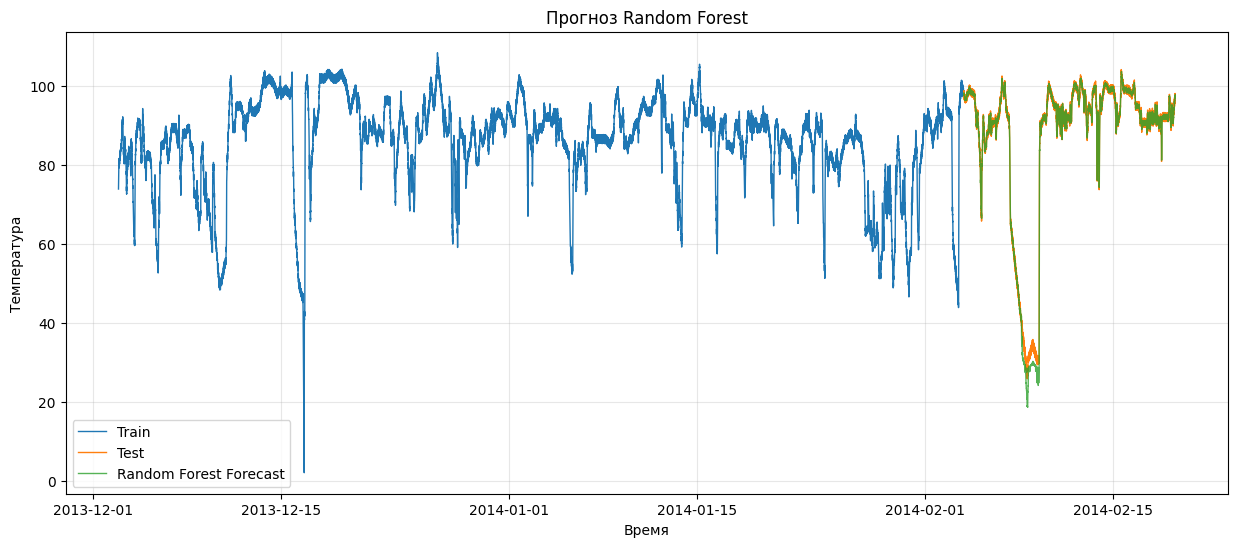

In [14]:
# Обучение Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Прогноз
rf_forecast = rf_model.predict(X_test)

# Метрики
rf_metrics = calculate_metrics(y_test, rf_forecast)
print("Метрики Random Forest:")
for metric, value in rf_metrics.items():
    print(f"{metric}: {value:.4f}")

# Визуализация
plt.figure(figsize=(15, 6))
plt.plot(train.index, train['value'], label='Train', linewidth=1)
plt.plot(test.index, test['value'], label='Test', linewidth=1)
plt.plot(y_test.index, rf_forecast, label='Random Forest Forecast', linewidth=1, alpha=0.8)
plt.title('Прогноз Random Forest')
plt.xlabel('Время')
plt.ylabel('Температура')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Random Forest продемонстрировала хорошие результаты с MAE 0.8213 и RMSE 1. Это подтверждает, что для данного стационарного ряда с высокой автокорреляцией достаточно простых подходов, а сложные модели не дают значимого улучшения. MAPE 1.62% показывает, что ошибка прогнозирования составляет менее 2%

Сравнение метрик всех моделей:
       Naive  Rolling Mean     ARIMA  Random Forest
MAE   0.8229       12.0680   13.4618         0.8213
MSE   1.0940      508.1037  372.8873         2.0249
RMSE  1.0459       22.5412   19.3103         1.4230
MAPE  1.0639       26.4847       NaN         1.6171


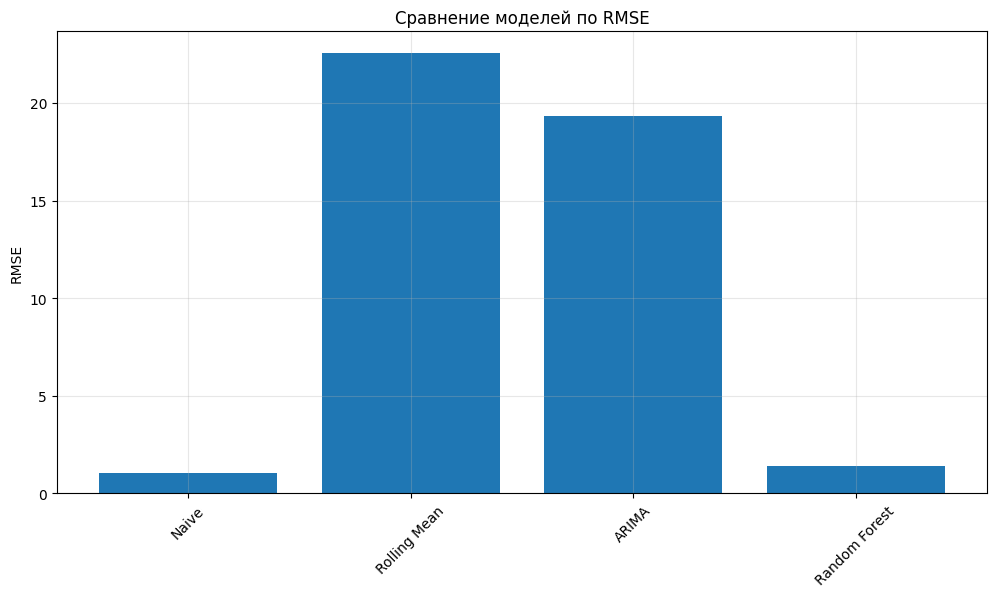

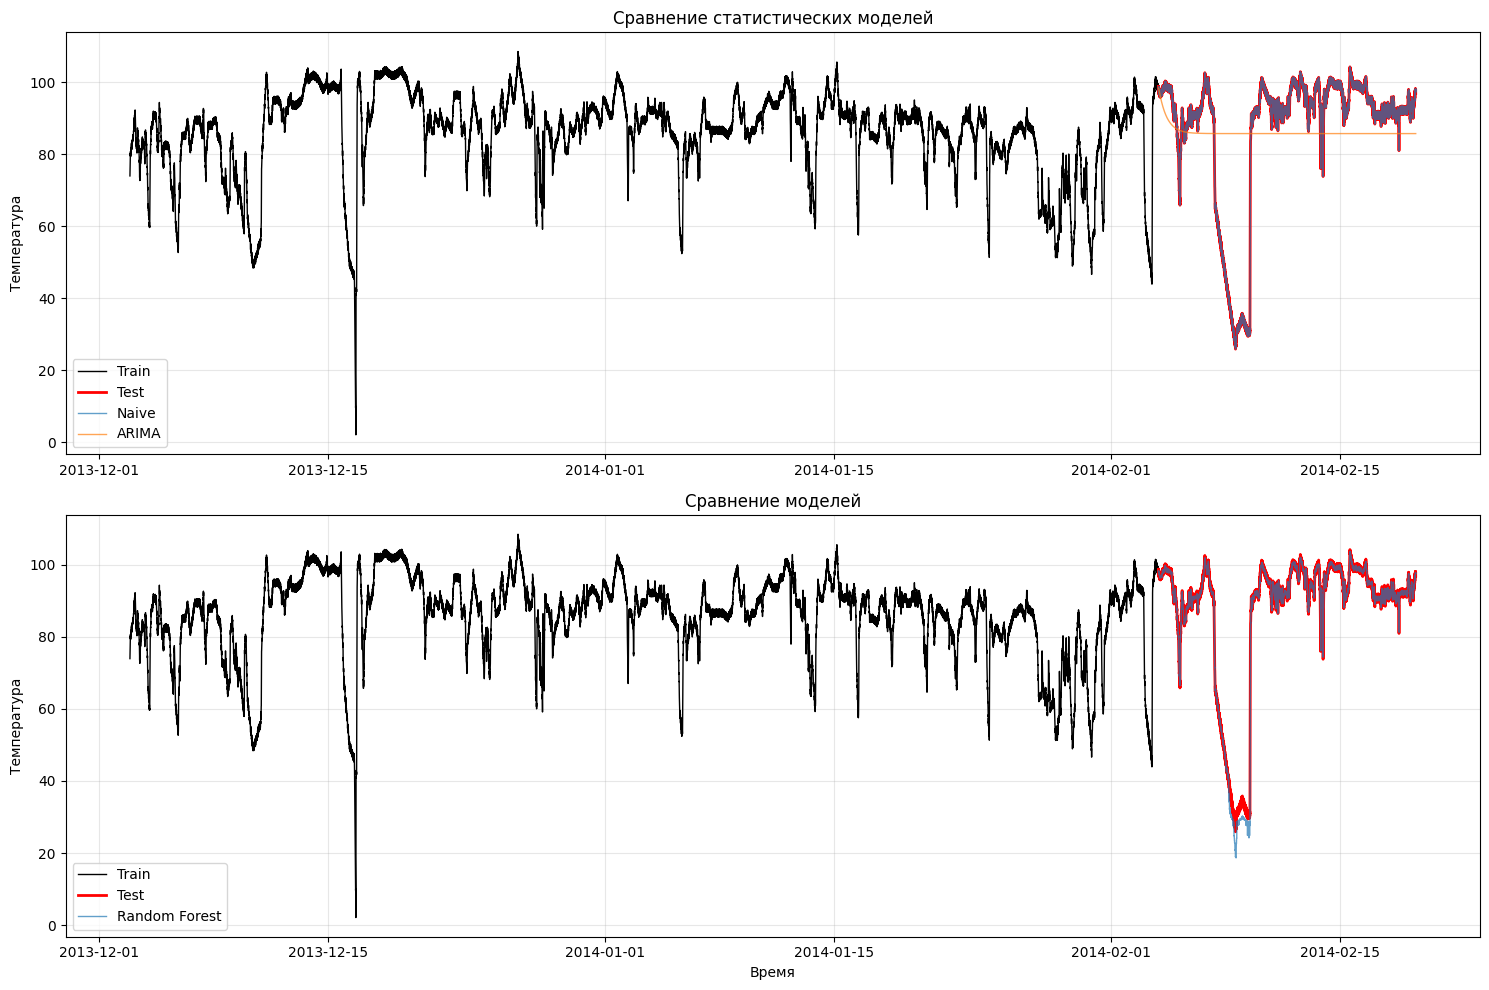

In [15]:
# Сравнение всех моделей
results = pd.DataFrame({
    'Naive': naive_metrics,
    'Rolling Mean': rolling_metrics,
    'ARIMA': arima_metrics,
    'Random Forest': rf_metrics,
})

print("Сравнение метрик всех моделей:")
print(results.round(4))

# Визуализация сравнения по RMSE
plt.figure(figsize=(12, 6))
models_to_plot = ['Naive', 'Rolling Mean', 'ARIMA', 'Random Forest']

rmse_values = [results.loc['RMSE', model] for model in models_to_plot]

plt.bar(models_to_plot, rmse_values)
plt.title('Сравнение моделей по RMSE')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

# Финальная визуализация всех прогнозов
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(train.index, train['value'], label='Train', linewidth=1, color='black')
plt.plot(test.index, test['value'], label='Test', linewidth=2, color='red')
plt.plot(test.index, naive_forecast, label='Naive', linewidth=1, alpha=0.7)
plt.plot(test.index, arima_forecast, label='ARIMA', linewidth=1, alpha=0.7)
plt.title('Сравнение статистических моделей')
plt.ylabel('Температура')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(train.index, train['value'], label='Train', linewidth=1, color='black')
plt.plot(test.index, test['value'], label='Test', linewidth=2, color='red')
plt.plot(test.index, rf_forecast, label='Random Forest', linewidth=1, alpha=0.7)

plt.title('Сравнение моделей')
plt.xlabel('Время')
plt.ylabel('Температура')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Выводы и заключение
print("="*50)
print("АНАЛИЗ РЕЗУЛЬТАТОВ")
print("="*50)

print("КАЧЕСТВО МОДЕЛЕЙ (по RMSE):")
best_model = results.loc['RMSE'].idxmin()
print(f"Лучшая модель: {best_model} (RMSE = {results.loc['RMSE', best_model]:.4f})")

АНАЛИЗ РЕЗУЛЬТАТОВ
КАЧЕСТВО МОДЕЛЕЙ (по RMSE):
Лучшая модель: Naive (RMSE = 1.0459)


Результат: для прогнозирования в нашем наборе модель (Naive) демонстрирует отличное качество, так же менее точный не не плохой результат выдал Random Forest. Статистическая модель ARIMA показала неэффективными результат с ошибками в 15-80 раз выше, причиной тому неподходящий ряд данных или ошибки в настройке.